In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
df=pd.read_parquet('CWRU_raw_data_1_load.parquet')
print(df.head())

    DE_data fault
0  0.046104   N_1
1 -0.037134   N_1
2 -0.089496   N_1
3 -0.084906   N_1
4 -0.038594   N_1


In [3]:
# Extract full signal as numpy array
signal = df["DE_data"].values

# Compute median and MAD over whole signal
median = np.median(signal)
mad = np.median(np.abs(signal - median))

# Avoid divide by zero
if mad == 0:
    signal_norm = signal - median
else:
    signal_norm = (signal - median) / mad*(1.4826)

# Put back into dataframe
df["signal_norm"] = signal_norm

In [4]:
print(df["signal_norm"].describe())

count    2.312052e+06
mean    -2.025917e-02
std      9.226778e+00
min     -1.551913e+02
25%     -1.532796e+00
50%      0.000000e+00
75%      1.435177e+00
max      1.792609e+02
Name: signal_norm, dtype: float64


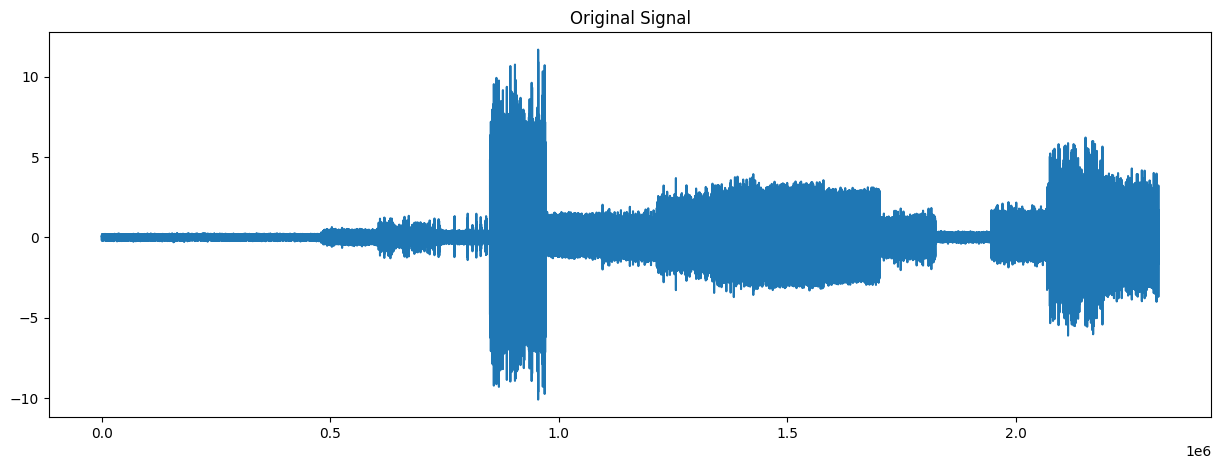

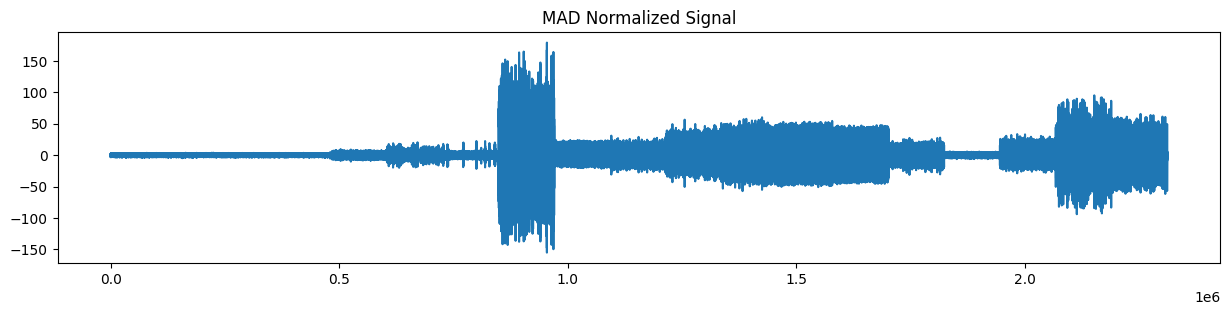

In [5]:
plt.figure(figsize=(15,5))
plt.plot(df["DE_data"])
plt.title("Original Signal")
plt.show()

plt.figure(figsize=(15,3))
plt.plot(df["signal_norm"])
plt.title("MAD Normalized Signal")
plt.show()